## White noise and autocorrelation


If the random variables which make up $y_t$ are uncorrelated and have a mean of 0 and variance $\sigma^2$, which do not change over time, then $y_t$ is considered stationary. Autocovariance is a statistical measure that quantifies the degree to which a time series is correlated with a lagged version of itself, and for this type of series the autocovariance function is

$$
\gamma_w(s,t) = \text{cov}(w_s, w_t)=
\begin{cases}
\sigma^2_w  & s=t \\
0 & \text{otherwise}
\end{cases}
$$

This type of series is referred to as [**white noise**](https://en.wikipedia.org/wiki/White_noise). The designation *white* originates from the analogy with white light and indicates that all possible periodic oscillations are present with equal strength ([Shumway and Stoffer 2011](http://www.springer.com/gp/book/9783319524511)).

As can be seen from the autocovariance function given above, the autocovariance is zero for the white noise (except when the series is compared with itself without any time shift (s = t)), meaning that the random variables $y_t$ of the series do not influence each other. This is expected because white noise is by definition uncorrelated between different time points.

A particularly useful white noise series is *Gaussian white noise*, wherein the $w_t$ are independent and identically distributed (*iid*) normal random variables, with mean 0 and variance $\sigma^2$.

$$w_t \sim \text{iid } N(0, \sigma^2_w) $$

We can easily generate a series of Gaussian white noise in Python:


In [ ]:
%load_ext lab_black

In [ ]:
# Importing necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
import random
from pandas import Series
from pandas.plotting import autocorrelation_plot

In [8]:
# Seed random number generator
random.seed(1)

# Create gaussian white noise series
series = [random.gauss(0.0, 1.0) for i in range(100)]
series = Series(series)

# Display summary stats
print(series.describe())

count    100.000000
mean      -0.050576
std        0.944013
min       -2.835791
25%       -0.609139
50%        0.010431
75%        0.556549
max        2.389112
dtype: float64


<Figure size 1800x600 with 0 Axes>

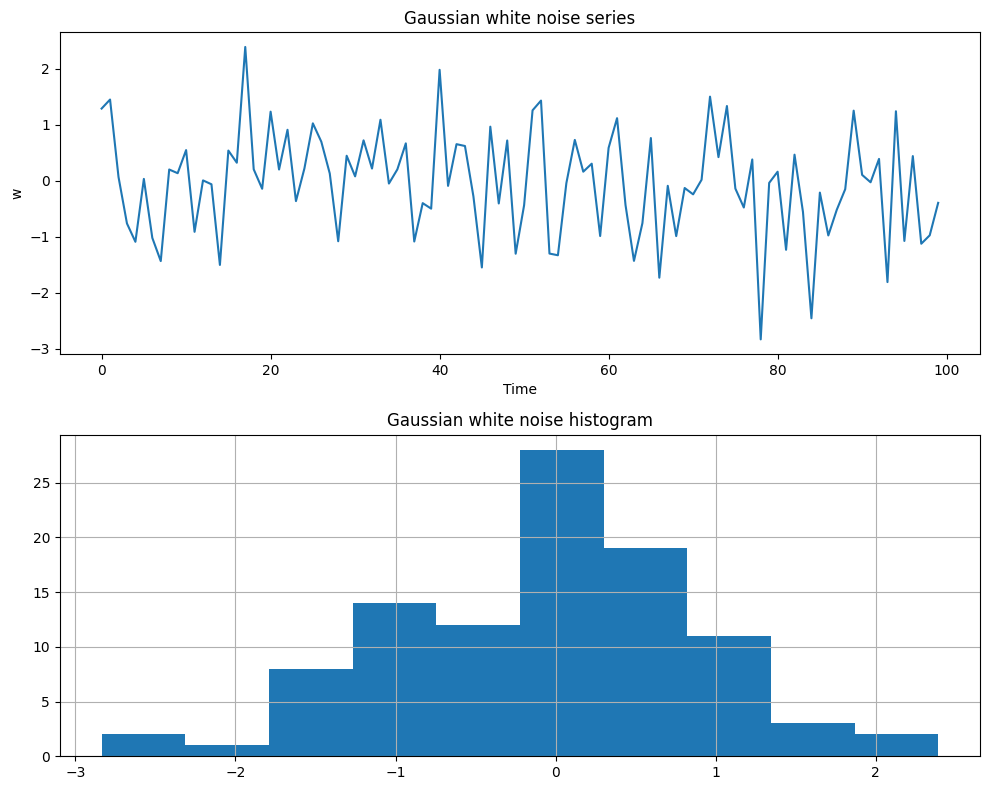

In [9]:
# Plot the series
plt.figure(figsize=(18, 6))
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

series.plot(ax=axs[0])
axs[0].set_title("Gaussian white noise series")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("w")

# Histogram plot
series.hist(ax=axs[1])
axs[1].set_title("Gaussian white noise histogram")

plt.tight_layout()
plt.show()

Let us plot the correlogram, a plot of the autocorrelation at different time lags, by using the [`autocorrelation_plot()`](https://pandas.pydata.org/docs/reference/api/pandas.plotting.autocorrelation_plot.html) function. Where the horizontal lines in the plot correspond to 95% (grey solid) and 99% (grey dashed) confidence bands.

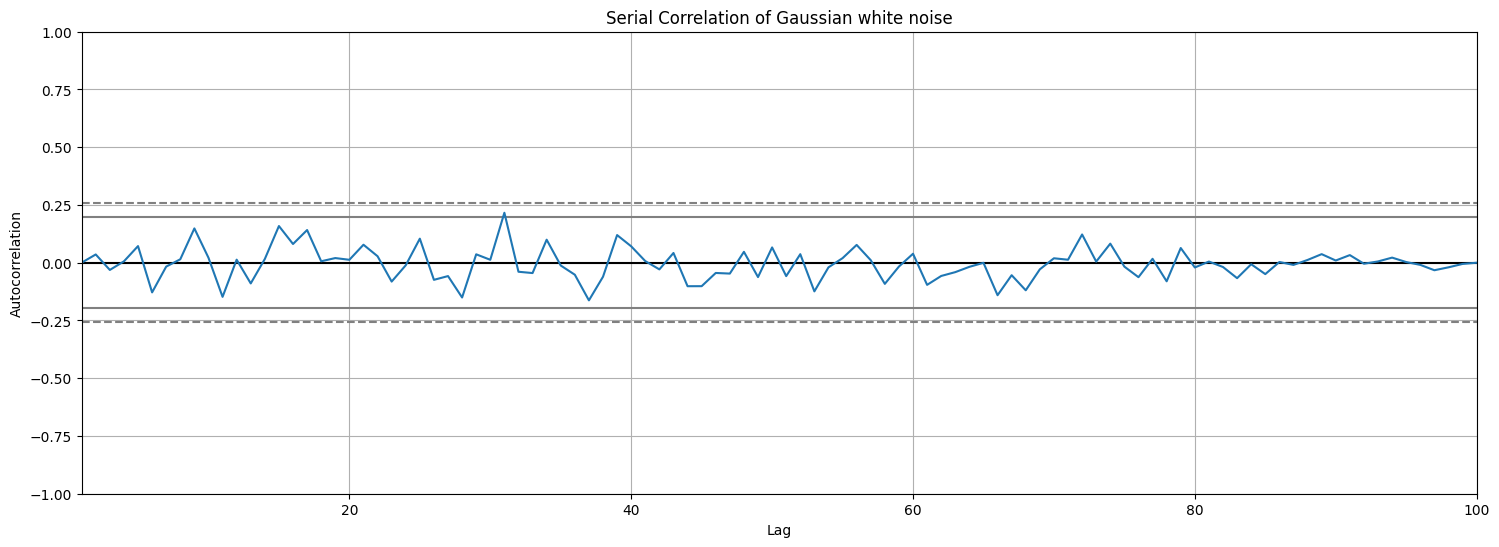

In [10]:
# Plot the correlogram
plt.figure(figsize=(18, 6))

autocorrelation_plot(series)
plt.title("Serial Correlation of Gaussian white noise")
plt.show()

The correlogram does not show any obvious autocorrelation pattern and non of the autocorrelations are significantly non-zero. Although there is one spike above the 95% confidence level, which is considered a statistical fluke.


### What is partial autocorrelation?

Autocorrelation is simply the correlation of a series with its own lags. If a series is significantly autocorrelated, that means, the previous values of the series (lags) may be helpful in predicting the current value.

Partial Autocorrelation also conveys similar information to Autocorrelation but it conveys the pure correlation of a series and its lag, excluding the correlation contributions from the intermediate lags.

A lag plot is a scatter plot of a time series against a lag of itself and it is normally used to check for autocorrelation. If there is any pattern existing in the series, the series is autocorrelated, and if there is no such pattern, the series is likely to be white noise. 

The [`pandas.plotting`](https://pandas.pydata.org/pandas-docs/stable/reference/plotting.html) provides the [`lag_plot`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.plotting.lag_plot.html) function for easy plotting. The uncorrelated guassian white noise which shows no pattern in the lag plots, and an example of an autocorrelated series which shows a linear relationship in the lag plots are shown below. 

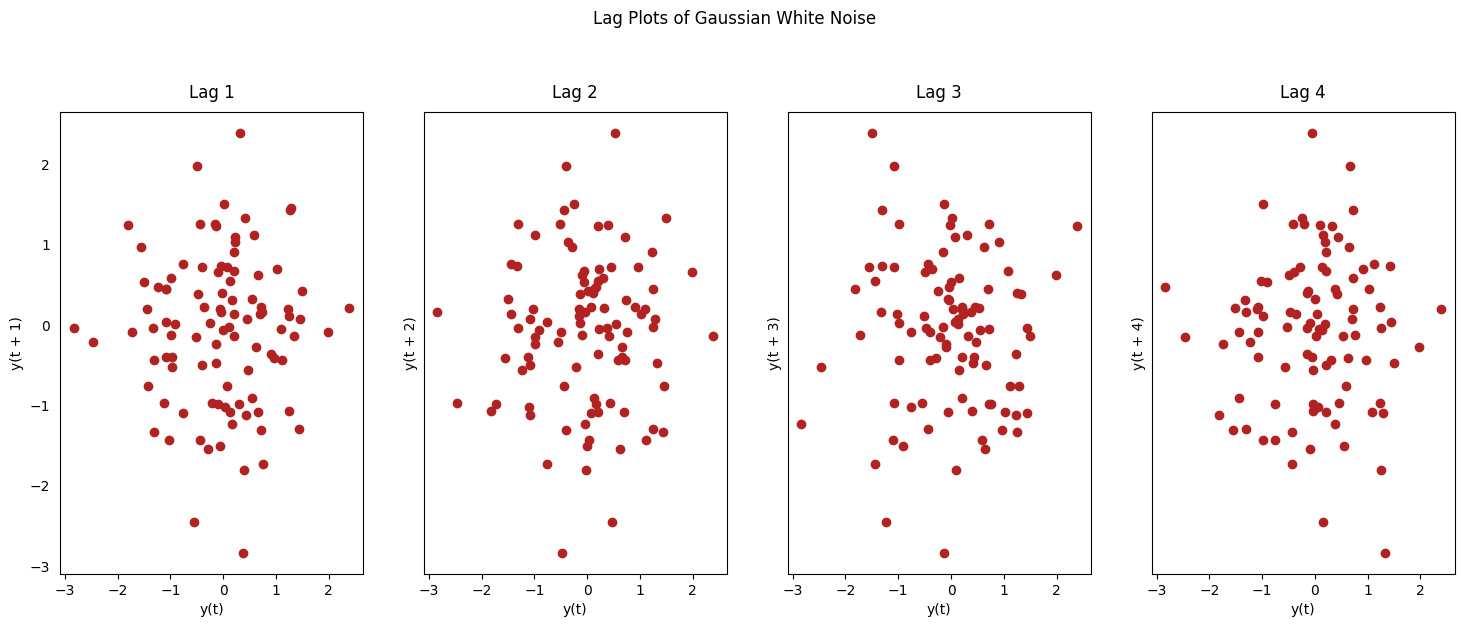

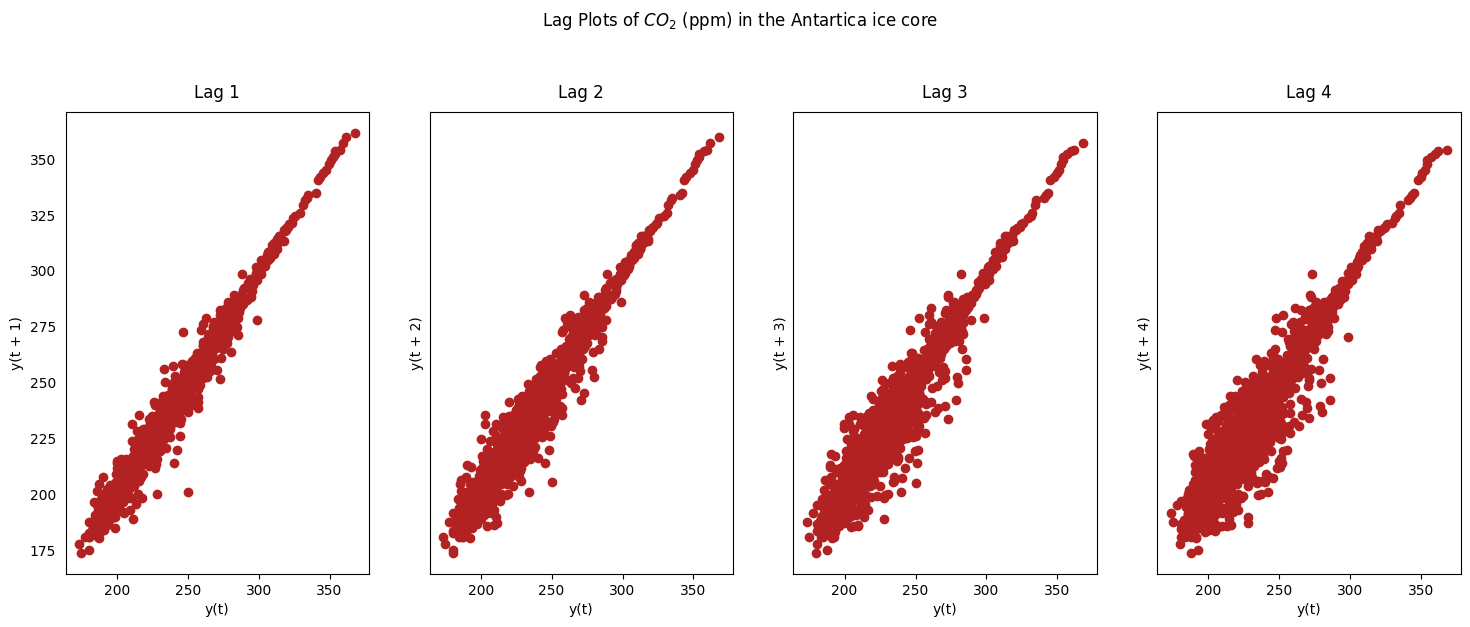

In [14]:
from pandas.plotting import lag_plot

plt.rcParams.update({"ytick.left": False, "axes.titlepad": 10})

# Plots for gaussian white noise
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharex=True, sharey=True, dpi=100)

for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(series, lag=i + 1, ax=ax, c="firebrick")
    ax.set_title("Lag " + str(i + 1))

fig.suptitle("Lag Plots of Gaussian White Noise", y=1.05)

plt.show()

# Import example time series, Antartica ice core data
ice_core = pd.read_json(
    "http://userpage.fu-berlin.de/soga/soga-py/300/307000_time_series/Antartica_Ice_Core.json"
)
ice_core = (
    pd.read_json(
        "http://userpage.fu-berlin.de/soga/soga-py/300/307000_time_series/Antartica_Ice_Core.json"
    )
    .set_index("ky_BP_AICC2012")
    .squeeze()
)
ice_core

# Plot for autocorrelated example, Antartica ice core data
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(ice_core, lag=i + 1, ax=ax, c="firebrick")
    ax.set_title("Lag " + str(i + 1))

fig.suptitle("Lag Plots of $CO_2$ (ppm) in the Antartica ice core ", y=1.05)
plt.show()

## Summary: 
* White noise time series is defined by a zero mean, constant variance, and zero correlation.
* If your time series is white noise, it cannot be predicted, and if your forecast residuals are not white noise, you may be able to improve your model.
* The statistics and diagnostic plots of Autocorrelation and Partial Autocorrelation can be used on your time series to check if it is white noise.

In [11]:
import urllib.request

fp = urllib.request.urlopen("https://userpage.fu-berlin.de/soga/soga-py/citation/citation_py.html")
mybytes = fp.read()

citation = mybytes.decode("utf8")
fp.close()

from IPython.display import display, HTML
display(HTML(citation))